# <p style="padding:10px; background-color:#1e3a8a; color:white; border-radius:10px; font-size:26px; font-weight:bold; text-align:center;">📊 Understanding Customer Churn in Telecom</p>

### 🌐 The Industry Landscape
**Customer churn** occurs when subscribers terminate their relationship with a service provider. In the hyper-competitive telecommunications market, consumers face low switching costs and an abundance of choice, resulting in an aggressive **annual industry churn rate of 15% to 25%**. 

### 🎯 The Corporate Retention Paradox
Providing high-touch, personalized care for an entire user base is operationally impossible. The massive volume of active accounts means that devoting equal retention resources to every consumer creates unsustainable overhead, quickly wiping out incremental revenue gains. 

> 💡 **The Data Science Counter-Strategy:** Instead of treating all accounts equally, we leverage **Predictive Segmentation**. By accurately forecasting which subscribers show early warning signs of attrition, corporate success teams can concentrate proactive retention budgets exclusively on verified, high-risk cohorts.

### 💼 The Critical Economic Impact
Maximizing a network's subscriber density directly lowers infrastructure maintenance costs per user, driving up baseline profit margins. Because customer acquisition costs (CAC) heavily outweigh customer retention costs (CRC), mitigating client attrition serves as a company's single most critical driver of sustainable revenue growth. 

To catch risk before a client walks away, an organization must build a **holistic, 360-degree consumer footprint**—scrutinizing product configurations, payment loops, service tiers, and pricing structures.

---

# <p style="padding:10px; background-color:#2c3e50; color:white; border-radius:10px; font-size:22px; font-weight:bold; text-align:center;">🎯 Core Analytical Objectives</p>

This comprehensive Exploratory Data Analysis (EDA) will break down the underlying patterns of customer behavior to answer five critical operational questions:

* 📊 **Baseline Attrition Breakdown**
  * *What is the exact baseline percentage of churned versus active, retained accounts across our database?*
* 👥 **Demographic Distribution Profiling**
  * *Do customer demographics (such as gender or family dependencies) exhibit any statistically valid correlations with churn?*
* 🛠️ **Product Configuration Friction**
  * *Which core product setups or secondary utility add-ons experience the highest relative volume of customer cancellations?*
* 💰 **Financial Burden Threshold Tracking**
  * *At what specific monthly pricing points do we hit a "price wall" that triggers massive customer attrition?*
* 💎 **Feature Ecosystem Value Matrix**
  * *Which specific product tiers and ecosystem combinations generate the highest customer loyalty and lifetime value?*

---


In [1]:
# Import Necessary Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')




In [2]:
import lightgbm as lgb
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import xgboost as xgb

In [3]:
# Loading the data
customer_churn = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = customer_churn.copy()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check the shape of the data
df.shape

(7043, 21)

In [5]:
# Check the summary about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# change the TotalCharges datatype to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
# Checking Missing values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
# Verify the gaps in TotalCharges column
df[df['TotalCharges'].isnull()][['tenure', 'TotalCharges']]

,tenure,TotalCharges
488,0,NaN
753,0,NaN
936,0,NaN
1082,0,NaN
1340,0,NaN
3331,0,NaN
3826,0,NaN
4380,0,NaN
5218,0,NaN
6670,0,NaN


In [9]:
# Fill the missing values
df["TotalCharges"] = df["TotalCharges"].fillna(0)
# 2. Verify that there are now 0 missing values left
print("Missing values remaining:", df['TotalCharges'].isnull().sum())

Missing values remaining: 0


In [10]:
# Drop the Customer ID column
df = df.drop('customerID', axis=1)

In [11]:
df.duplicated().sum()

np.int64(22)

In [12]:
df = df.drop_duplicates()

In [13]:
numerical_features = [feature for feature in df.columns if df[feature].dtypes != 'O']
categorical_features = [feature for feature in df.columns if feature not in numerical_features]
print('Number of numerical variables: ', len(numerical_features))
print('Number of categorical variables: ', len(categorical_features))
print('Numerical variables: ', numerical_features)
print('Categorical variables: ', categorical_features)

Number of numerical variables:  4
Number of categorical variables:  16
Numerical variables:  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical variables:  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [14]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5880
1    1141
Name: count, dtype: int64

# EDA(Exploratory Data Analysis)

## Phase1: Univariat Analysis

In [15]:
df['Churn'].value_counts(normalize=True)*100


Churn
No     73.550776
Yes    26.449224
Name: proportion, dtype: float64

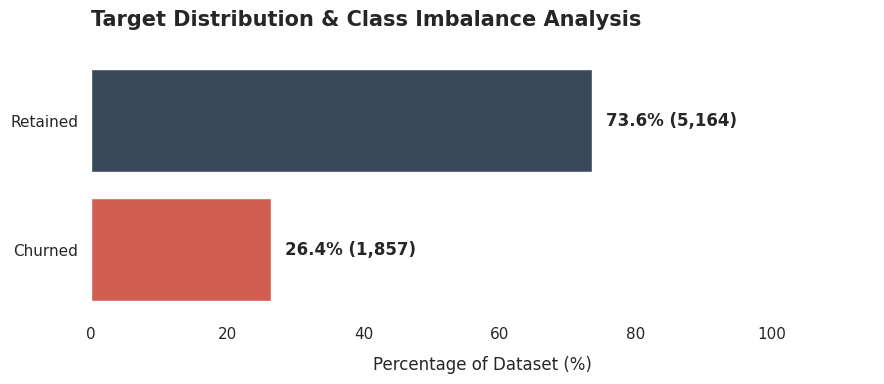

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup the aggregated data containing both metrics
counts = df['Churn'].value_counts()
percentages = df['Churn'].value_counts(normalize=True) * 100

# Convert to a clean plotting DataFrame
dist_df = counts.to_frame(name='Count').join(percentages.to_frame(name='Percentage')).reset_index()
dist_df.columns = ['Status', 'Count', 'Percentage']

# Professional Mapping: Replace original categories with business-ready labels
# (Handles both string 'No'/'Yes' or numeric 0/1 depending on your upstream preprocessing)
status_map = {'No': 'Retained', 'Yes': 'Churned', 0: 'Retained', 1: 'Churned'}
dist_df['Status'] = dist_df['Status'].map(status_map)

# 2. Design the canvas
sns.set_theme(style="white", context="notebook")
fig, ax = plt.subplots(figsize=(9, 4))

# 3. Create the horizontal visualization
sns.barplot(
    data=dist_df,
    x='Percentage',
    y='Status',
    orient='h',
    palette=['#34495E', '#E74C3C'],
    ax=ax  # Explicitly passing the axis object is a data science best practice
)

# 4. Annotate with BOTH raw counts and percentages on the same line
for i, bar in enumerate(ax.patches):
    pct = dist_df.loc[i, 'Percentage']
    cnt = dist_df.loc[i, 'Count']

    # Combined string pattern: "Percentage% (Count)" -> "73.4% (7,340)"
    label_text = f"{pct:.1f}% ({cnt:,})"

    ax.annotate(
        label_text,
        (bar.get_width(), bar.get_y() + bar.get_height() / 2),
        ha='left',
        va='center',
        fontsize=12,
        weight='semibold',
        xytext=(10, 0),
        textcoords='offset points'
    )

# 5. Professional final styling
ax.set_title('Target Distribution & Class Imbalance Analysis', pad=22, weight='bold', fontsize=15, loc='left')
ax.set_xlabel('Percentage of Dataset (%)', labelpad=10)
ax.set_ylabel('')
ax.set_xlim(0, 115) # Generous bounds to safeguard against text truncation
sns.despine(left=True, bottom=True)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()


The dataset is characterized by a 73.5% to 26.5% imbalanced split between retained and churned customers, indicating a baseline accuracy hurdle for upcoming predictive modeling

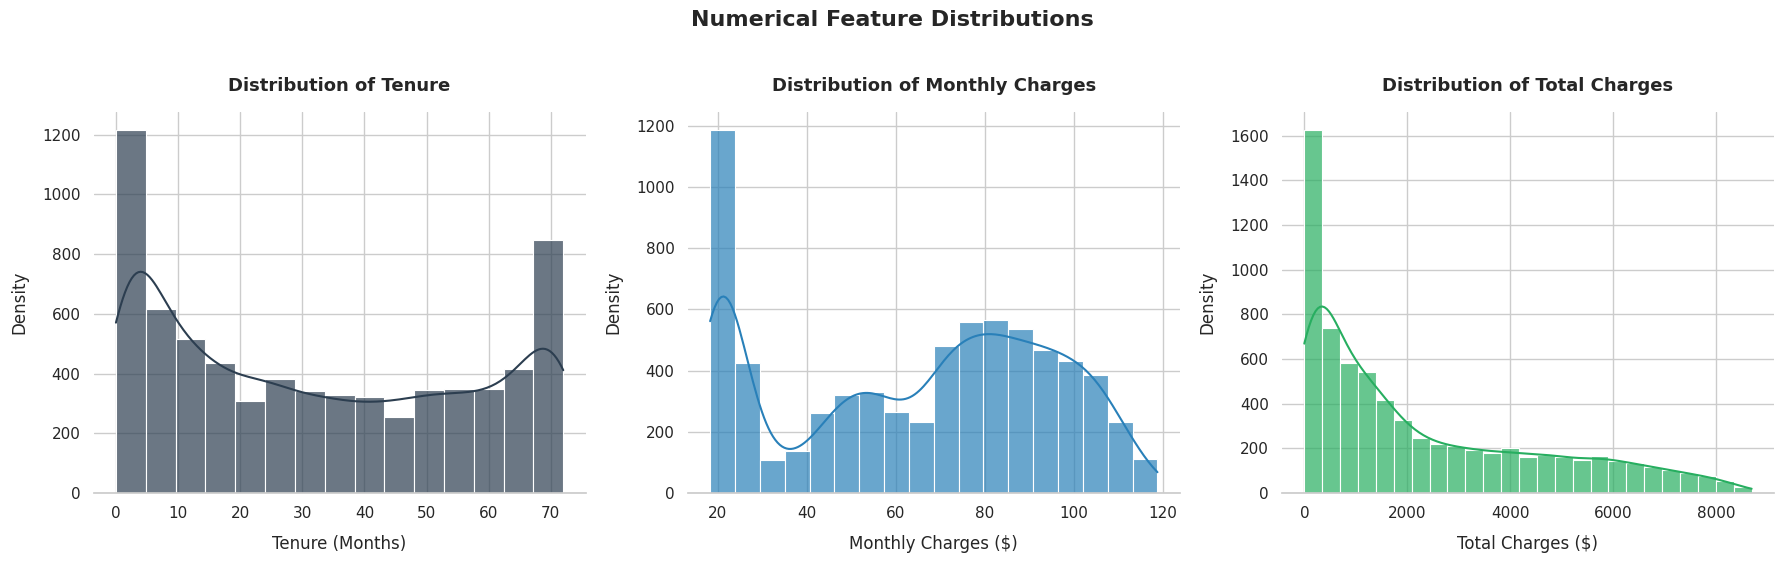

In [17]:
features_config = {
    'tenure': {'title': 'Distribution of Tenure', 'xlabel': 'Tenure (Months)', 'color': '#2C3E50'},
    'MonthlyCharges': {'title': 'Distribution of Monthly Charges', 'xlabel': 'Monthly Charges ($)', 'color': '#2980B9'},
    'TotalCharges': {'title': 'Distribution of Total Charges', 'xlabel': 'Total Charges ($)', 'color': '#27AE60'}
}

# 3. Establish consistent professional visual theme
sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=False)

# 4. Programmatic looping over axes to minimize code redundancy
for ax, (col, cfg) in zip(axes, features_config.items()):
    # Plot histogram with Kernel Density Estimate (KDE) line
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=ax,
        color=cfg['color'],
        edgecolor='white',
        linewidth=0.8,
        alpha=0.7
    )

    # Customizing the explicit axis components
    ax.set_title(cfg['title'], pad=15, weight='bold', fontsize=13)
    ax.set_xlabel(cfg['xlabel'], labelpad=10)
    ax.set_ylabel('Density' if ax.get_ylabel() else '', labelpad=10)

    # Stylistic cleanups
    sns.despine(ax=ax, left=True, bottom=False)

# 5. Global figure layout adjustments
fig.suptitle('Numerical Feature Distributions', weight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

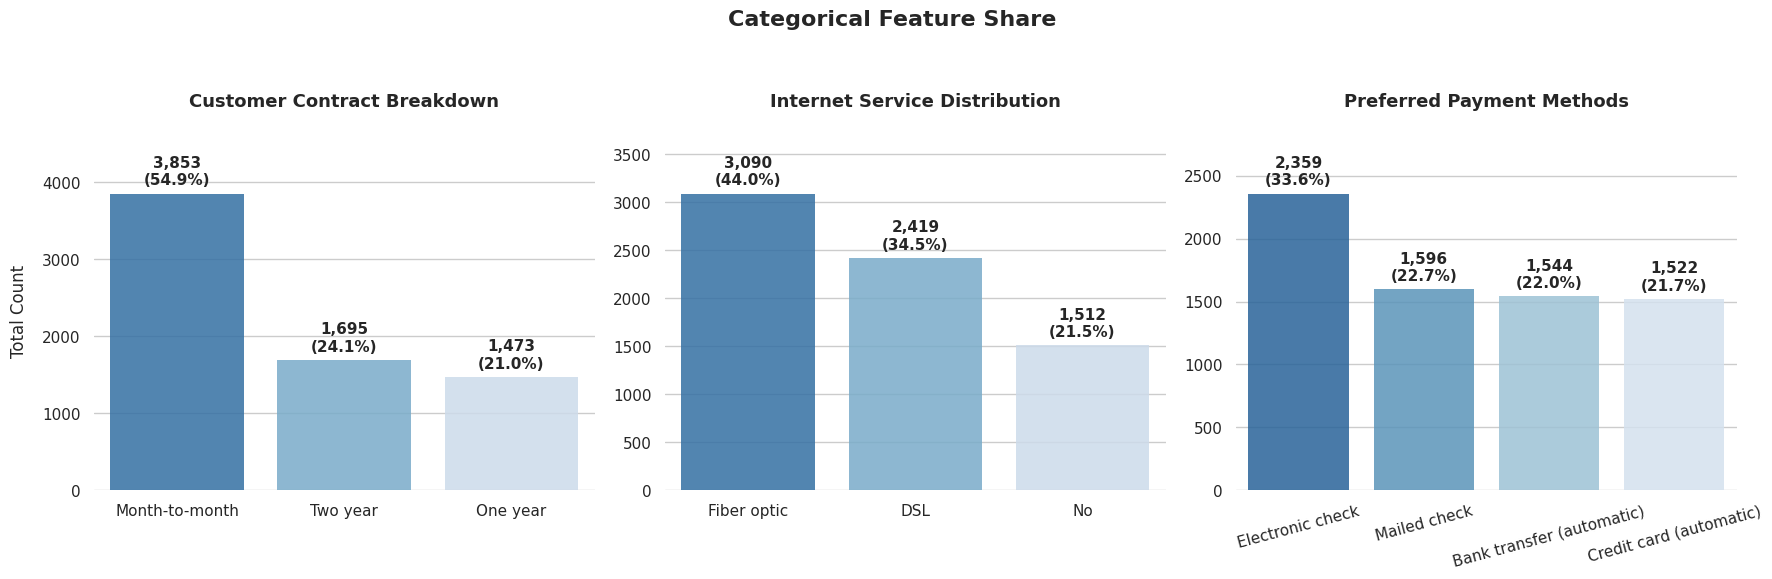

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define configuration mapping for categorical columns
categorical_config = {
    'Contract': {'title': 'Customer Contract Breakdown', 'rotation': 0},
    'InternetService': {'title': 'Internet Service Distribution', 'rotation': 0},
    'PaymentMethod': {'title': 'Preferred Payment Methods', 'rotation': 15}
}

# 2. Establish a consistent, professional design theme
sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=False)

total_rows = len(df)

# 3. Programmatic loop execution
for i, (ax, (col, cfg)) in enumerate(zip(axes, categorical_config.items())):

    # --- FIXED LOGIC: Sort categories by value counts to ensure highest bars are darkest ---
    sorted_order = df[col].value_counts().index

    # Plot using 'Blues_r' (reversed) palette so the first item (highest count) gets the darkest color
    sns.countplot(
        data=df,
        x=col,
        order=sorted_order,
        ax=ax,
        palette='Blues_r',
        edgecolor='none',
        alpha=0.85
    )

    # 4. Dynamically compute and overlay Count + Percentage labels on top of bars
    for bar in ax.patches:
        y_value = bar.get_height()
        if y_value > 0:
            percentage = (y_value / total_rows) * 100
            label_text = f"{y_value:,.0f}\n({percentage:.1f}%)" # Added .0f to clean up decimals from your labels

            ax.annotate(
                label_text,
                (bar.get_x() + bar.get_width() / 2, y_value),
                ha='center',
                va='bottom',
                fontsize=11,
                weight='bold',
                xytext=(0, 4),
                textcoords='offset points'
            )

    # 5. Fine-tune layout parameters per subplot
    ax.set_title(cfg['title'], pad=18, weight='bold', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Total Count' if i == 0 else '', labelpad=10)
    ax.tick_params(axis='x', rotation=cfg['rotation'], labelsize=11)

    # Expand vertical boundaries slightly to safeguard label placement
    current_ymin, current_ymax = ax.get_ylim()
    ax.set_ylim(current_ymin, current_ymax * 1.15)

    sns.despine(ax=ax, left=True, bottom=True)

# 6. Global formatting polish
fig.suptitle('Categorical Feature Share', weight='bold', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()


## Phase 2: Bivariate Analysis

In [19]:
# Calculate the exact churn rate difference between seniors and non-seniors
df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100


Churn,No,Yes
SeniorCitizen,,
0,76.496599,23.503401
1,58.369851,41.630149


### Let's Visualize it

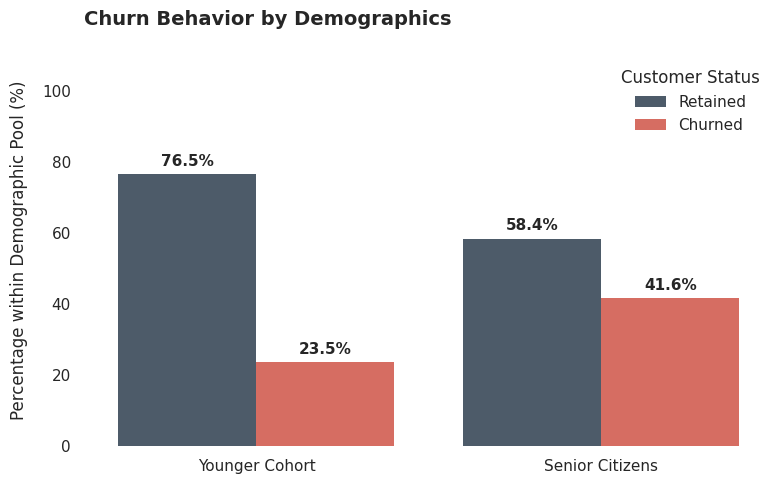

In [20]:

# 1. Prepare and cleanly structure the bivariate data
# Group by the feature and target to calculate precise segment percentages
bivariate_df = (
    df.groupby('SeniorCitizen')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

# Map values to highly intuitive, business-ready terminology for presentation
bivariate_df['SeniorCitizen'] = bivariate_df['SeniorCitizen'].map({0: 'Younger Cohort', 1: 'Senior Citizens'})
bivariate_df['Churn'] = bivariate_df['Churn'].map({'No': 'Retained', 'Yes': 'Churned', 0: 'Retained', 1: 'Churned'})

# 2. Design a clean, distraction-free plotting layout
sns.set_theme(style="white", context="notebook")
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Render a grouped bar chart for clear subset comparison
sns.barplot(
    data=bivariate_df,
    x='SeniorCitizen',
    y='Percentage',
    hue='Churn',
    palette=['#34495E', '#E74C3C'], # Matching your exact corporate theme
    edgecolor='none',
    alpha=0.9,
    ax=ax
)

# 4. Programmatically loop to apply data labels directly on top of the bars
for bar in ax.patches:
    y_value = bar.get_height()
    if y_value > 0:
        ax.annotate(
            f'{y_value:.1f}%',
            (bar.get_x() + bar.get_width() / 2, y_value),
            ha='center',
            va='bottom',
            fontsize=11,
            weight='bold',
            xytext=(0, 4),
            textcoords='offset points'
        )

# 5. Professional final styling and framing
ax.set_title('Churn Behavior by Demographics', pad=22, weight='bold', fontsize=14, loc='left')
ax.set_xlabel('')
ax.set_ylabel('Percentage within Demographic Pool (%)', labelpad=10)
ax.set_ylim(0, 110) # Room for text annotations

# Reposition the legend cleanly so it doesn't overlap the plot content
ax.legend(title='Customer Status', loc='upper right', frameon=False)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


Senior citizens are churning at a much higher rate than our younger demographic. While nearly 3 out of 4 younger customers stay, over 40% of seniors leave the service.

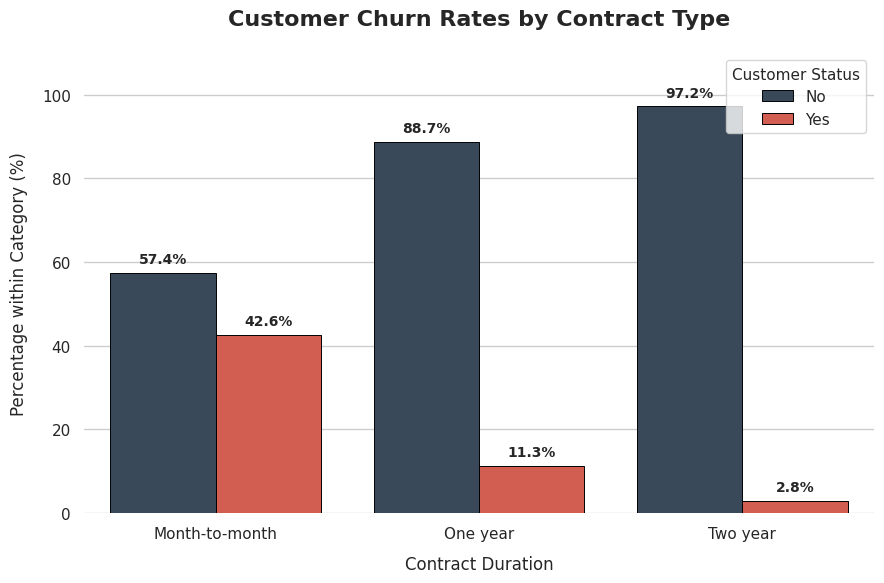

In [21]:

# Set a clean, professional aesthetic style
sns.set_theme(style="whitegrid", font="sans-serif")

# Group data to calculate the exact percentage of Churn within each Contract type
df_contract_pct = (
    df.groupby('Contract')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

# Create the figure with an optimized aspect ratio
plt.figure(figsize=(9, 6))

# Define a cohesive, professional color palette (Dark Slate vs. Warning Red)
custom_palette = ["#34495e", "#e74c3c"]

# create the normalized bar plot
ax = sns.barplot(
    data=df_contract_pct,
    x='Contract',
    y='Percentage',
    hue='Churn',
    palette=custom_palette,
    edgecolor="black",
    linewidth=0.7
)

# Title with strong visual hierarchy (large, bold, and padded)
plt.title('Customer Churn Rates by Contract Type', fontsize=16, fontweight='bold', pad=20)

# Clear, descriptive axis labels
plt.xlabel('Contract Duration', fontsize=12, labelpad=10)
plt.ylabel('Percentage within Category (%)', fontsize=12, labelpad=10)

# Clean up tick marks and leave padding room at the top for labels
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, 110)

# Dynamically add exact percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=10, fontweight='bold')

# Format the legend to be clear and unobtrusive
plt.legend(title='Customer Status', title_fontsize='11', loc='upper right', frameon=True)

# Despine the layout to remove visual border clutter
sns.despine(left=True, bottom=True)

# Tighten the layout boundary to prevent any clipping
plt.tight_layout()

# Display the visualization
plt.show()


# (Insight: You will quickly see Month-to-month contracts have the highest churn)


Customers on month-to-month plans are far more likely to leave than those on longer commitments. Churn drops drastically the moment a customer signs a one- or two-year contract.

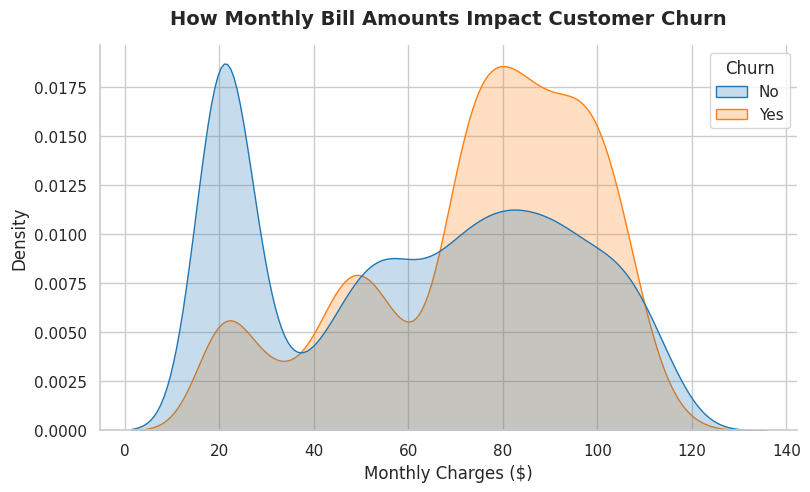

In [22]:
# Create a smooth distribution curve of monthly bills for stayed vs left customers
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette=['#1f77b4', '#ff7f0e'])
plt.title('How Monthly Bill Amounts Impact Customer Churn', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density')
sns.despine()
plt.show()


Our highest retention occurs at low price tiers, but we hit a critical "price wall" above $70. Customers paying between $70 and $100 a month represent our highest-density churn risk.

In [23]:
# Standard Telco dataset column names variation
print(df.groupby('TechSupport')['Churn'].value_counts(normalize=True)*100)


TechSupport          Churn
No                   No       58.499278
                     Yes      41.500722
No internet service  No       92.791005
                     Yes       7.208995
Yes                  No       84.833659
                     Yes      15.166341
Name: proportion, dtype: float64


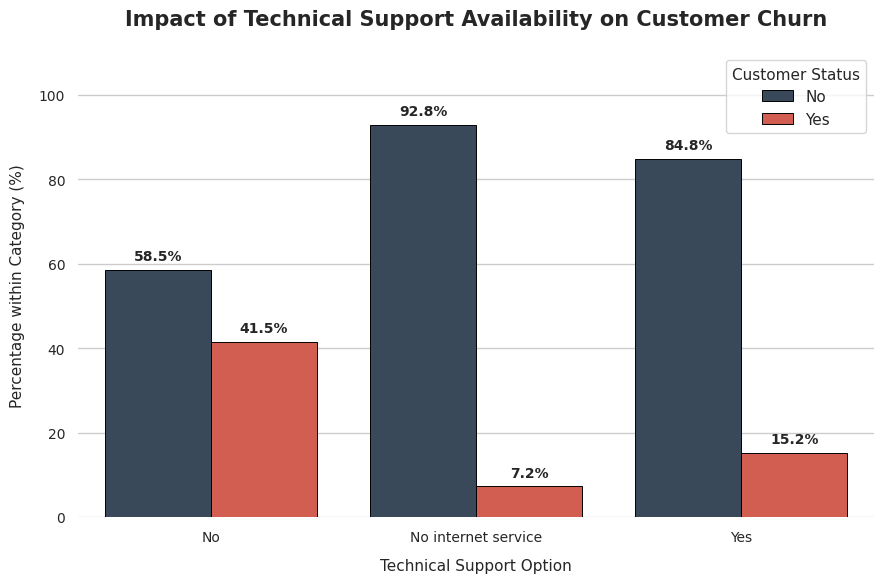

In [24]:
# Check if customers without tech support are leaving faster
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional aesthetic style
sns.set_theme(style="whitegrid", font="sans-serif")

# Group data to calculate the exact percentage of Churn within each TechSupport category
df_pct = (
    df.groupby('TechSupport')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

# Set figure size and custom professional color palette
plt.figure(figsize=(9, 6))
custom_palette = ["#34495e", "#e74c3c"]  # Polished dark slate for Retained, warning red for Churned

# Generate the normalized bar plot
ax = sns.barplot(
    data=df_pct,
    x='TechSupport',
    y='Percentage',
    hue='Churn',
    palette=custom_palette,
    edgecolor="black",
    linewidth=0.7
)

# Title with strong visual hierarchy
plt.title('Impact of Technical Support Availability on Customer Churn', fontsize=15, fontweight='bold', pad=20)

# Clear, descriptive axis labels
plt.xlabel('Technical Support Option', fontsize=11, labelpad=10)
plt.ylabel('Percentage within Category (%)', fontsize=11, labelpad=10)

# Clean up tick mark styling and set y-axis limits to leave room for labels
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 110)

# Add exact percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=10, fontweight='bold')

# Position and style the legend cleanly
plt.legend(title='Customer Status', title_fontsize='11', loc='upper right', frameon=True)

# Despine the layout to remove visual clutter
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Display the visualization
plt.show()


Customers who do not receive tech support are nearly three times more likely to churn than those who do. Providing tech support drops the churn rate significantly from over 41% down to just 15%.

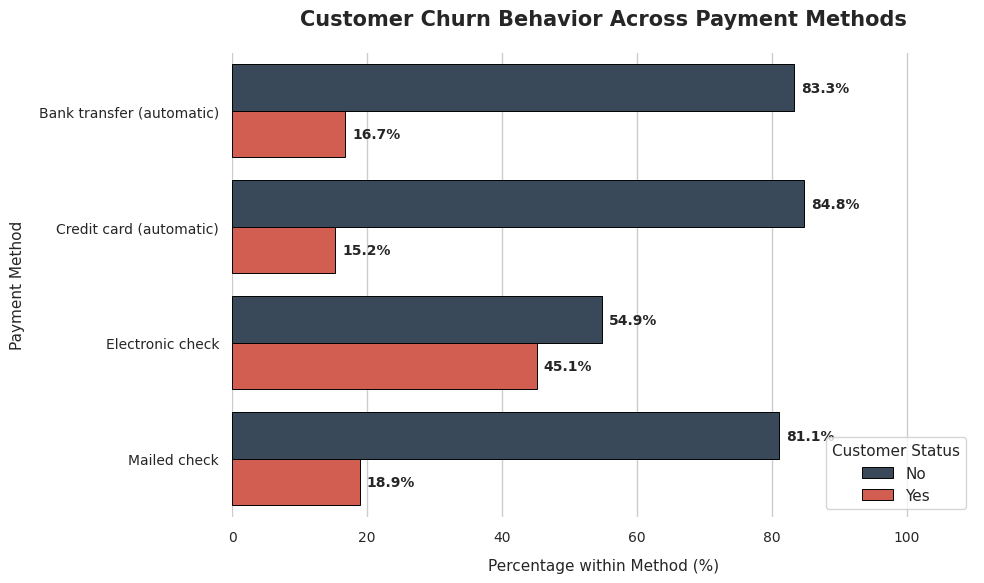

In [25]:
# Set a clean, professional aesthetic style
sns.set_theme(style="whitegrid", font="sans-serif")

# Group data to calculate the exact percentage of Churn within each PaymentMethod category
df_payment_pct = (
    df.groupby('PaymentMethod')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

# Create a figure optimized for horizontal bar structures
plt.figure(figsize=(10, 6))

# Define a cohesive, professional color palette (Dark Slate vs. Warning Red)
custom_palette = ["#34495e", "#e74c3c"]

# Generate the normalized horizontal bar plot
ax = sns.barplot(
    data=df_payment_pct,
    y='PaymentMethod',  # Placed on y-axis for horizontal display
    x='Percentage',     # Placed on x-axis to show distribution scale
    hue='Churn',
    palette=custom_palette,
    edgecolor="black",
    linewidth=0.7
)

# Title with strong visual hierarchy (large, bold, and padded)
plt.title('Customer Churn Behavior Across Payment Methods', fontsize=15, fontweight='bold', pad=20)

# Clear, descriptive axis labels
plt.xlabel('Percentage within Method (%)', fontsize=11, labelpad=10)
plt.ylabel('Payment Method', fontsize=11, labelpad=10)

# Clean up tick mark styling and leave padding room on the right side for labels
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 110)

# Dynamically add exact percentage labels next to each horizontal bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=10, fontweight='bold')

# Format the legend to be clear and unobtrusive
plt.legend(title='Customer Status', title_fontsize='11', loc='lower right', frameon=True)

# Despine the layout to remove visual border clutter
sns.despine(left=True, bottom=True)

# Tighten the layout boundary to prevent any clipping of long category labels
plt.tight_layout()

# Display the visualization
plt.show()


Customers paying by Electronic Check are nearly three times more likely to churn than those on automated payment options. Shifting users from manual electronic checks to credit cards or automatic bank transfers cuts churn by roughly two-thirds.

## Phase 3: Multivariate Analysis

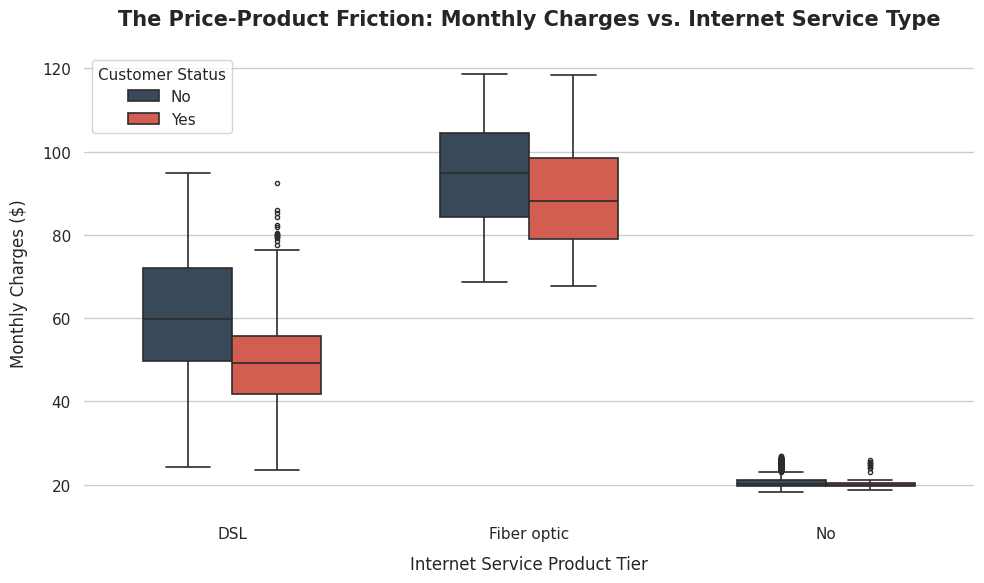

In [26]:

# Set a clean, presentation-ready theme
sns.set_theme(style="whitegrid", font="sans-serif")

# Define your signature professional palette (Dark Slate vs. Warning Red)
previous_palette = {"No": "#34495e", "Yes": "#e74c3c"}

# Create a figure optimized for distribution comparisons
plt.figure(figsize=(10, 6))

# Generate a split box plot to compare price points and churn across service types
ax = sns.boxplot(
    data=df,
    x='InternetService',
    y='MonthlyCharges',
    hue='Churn',
    palette=previous_palette,
    width=0.6,
    linewidth=1.2,
    fliersize=3  # Controls the visibility of outlier points cleanly
)

# Title with strong visual hierarchy
plt.title('The Price-Product Friction: Monthly Charges vs. Internet Service Type', fontsize=15, fontweight='bold', pad=20)

# Clear, descriptive axis labels
plt.xlabel('Internet Service Product Tier', fontsize=12, labelpad=10)
plt.ylabel('Monthly Charges ($)', fontsize=12, labelpad=10)

# Clean up tick mark styling
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Format the legend to match the rest of your presentation deck
plt.legend(title='Customer Status', title_fontsize='11', loc='upper left', frameon=True)

# Despine the layout to remove visual border clutter
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Display the visualization
plt.show()


Our premium Fiber Optic tier is forcing customers into a dangerously high pricing bracket that directly triggers mass attrition. Fiber Optic subscribers are paying a premium baseline of  $80$  to $110 a month, making price sensitivity the primary catalyst for our overall customer losses.

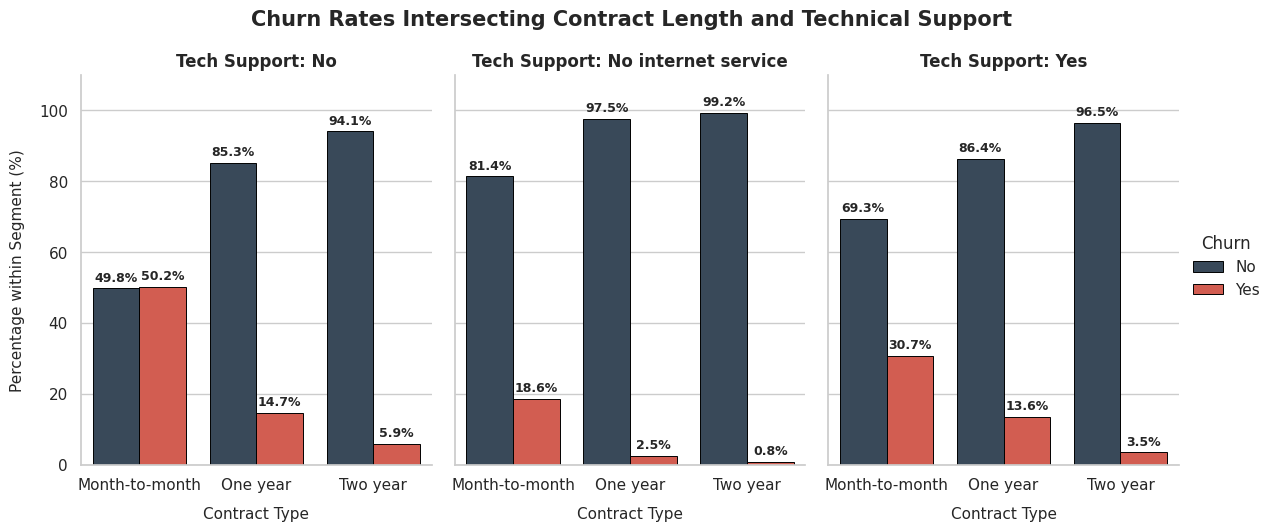

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, presentation-ready theme
sns.set_theme(style="whitegrid", font="sans-serif")

# Group data to calculate the exact percentage of Churn within the intersecting segments
df_multi1 = (
    df.groupby(['Contract', 'TechSupport'])['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

previous_palette = {"No": "#34495e", "Yes": "#e74c3c"}

# Use Seaborn's CatPlot to create structured subplots side-by-side
g = sns.catplot(
    data=df_multi1,
    x='Contract',
    y='Percentage',
    hue='Churn',
    hue_order=['No', 'Yes'],
    col='TechSupport',
    kind='bar',
    palette=previous_palette,
    edgecolor="black",
    linewidth=0.7,
    height=5,
    aspect=0.8
)

# Polishing titles and structural spacing
g.set_titles("Tech Support: {col_name}", fontsize=12, fontweight='bold')
g.set_axis_labels("Contract Type", "Percentage within Segment (%)", fontsize=11, labelpad=10)
g.fig.suptitle("Churn Rates Intersecting Contract Length and Technical Support", fontsize=15, fontweight='bold', y=1.05)

# Add exact numeric data labels dynamically inside each subplot frame
for ax in g.axes.flat:
    ax.set_ylim(0, 110)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9, fontweight='bold')

plt.show()


Technical support serves as our most effective safety net for high-risk customers. Adding tech support to short-term, month-to-month contracts slashes their churn rate from a critical 50.4% down to 30.7%.

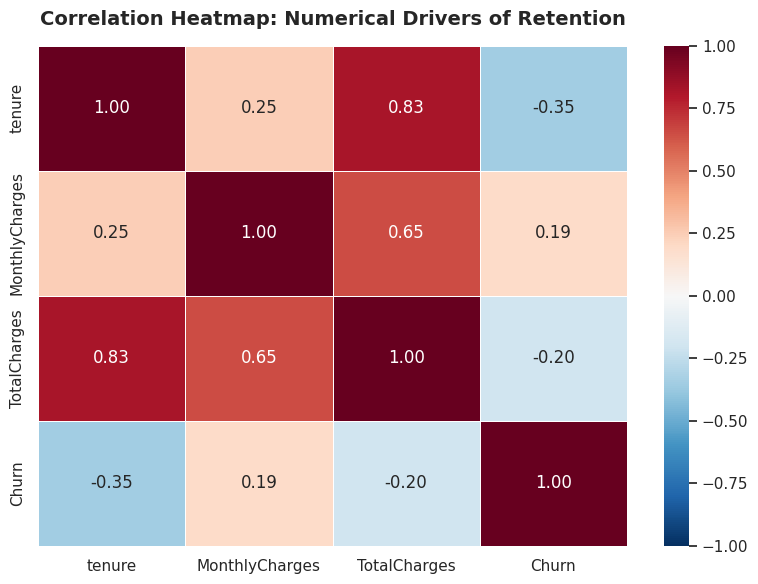

In [28]:
import numpy as np

plt.figure(figsize=(8, 6))

# Isolate numeric columns and map Churn to 1 (Yes) and 0 (No) for accurate correlation calculation
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Compute the correlation matrix calculation
corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu_r',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Heatmap: Numerical Drivers of Retention', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


Customer longevity is our single strongest defense against attrition. While higher monthly bills do introduce a minor churn risk, long-term tenure effectively overrides price sensitivity over time.

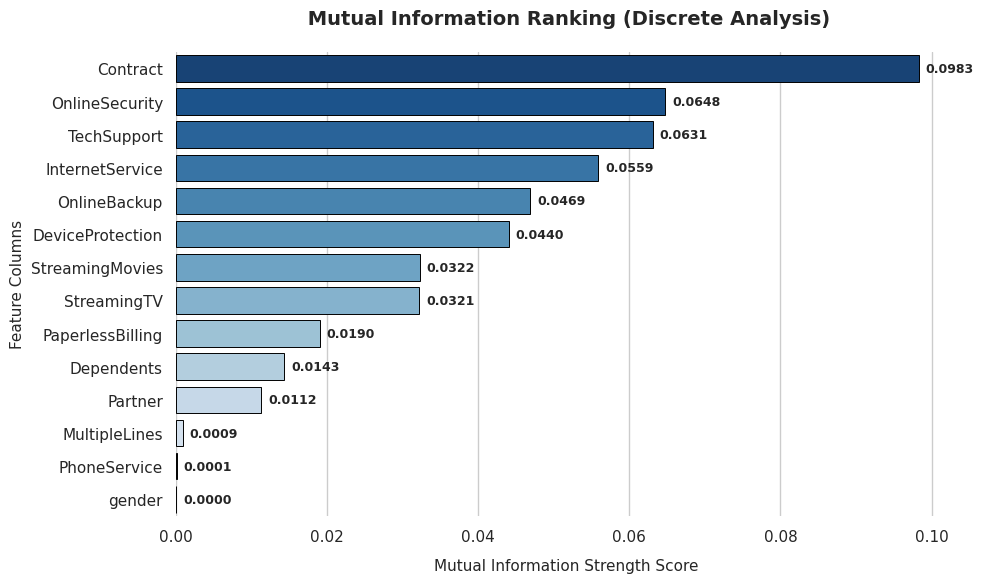

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

# 1. Target and features
target_column = 'Churn'
categorical_columns = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling'
]

# 2. Encode to single integers per column (keeps variables whole)
encoder = OrdinalEncoder()
X_discrete = encoder.fit_transform(df[categorical_columns].fillna('Unknown'))
y_encoded = df[target_column].map({'Yes': 1, 'No': 0})

# 3. Compute true MI by explicitly declaring all features as discrete
# This forces scikit-learn to use the exact discrete entropy formulas
mi_scores = mutual_info_classif(X_discrete, y_encoded, discrete_features=True, random_state=42)

# 4. Build sorted presentation frame cleanly without dictionary hacks
importance_df = pd.DataFrame({
    'Feature': categorical_columns,
    'ImportanceScore': mi_scores
}).sort_values(by='ImportanceScore', ascending=False).reset_index(drop=True)

# ==========================================
# PRESENTATION VISUALIZATION
# ==========================================
sns.set_theme(style="whitegrid", font="sans-serif")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=importance_df,
    y='Feature',
    x='ImportanceScore',
    palette=sns.color_palette("Blues_r", n_colors=len(importance_df)),
    edgecolor="black",
    linewidth=0.7
)

plt.title(' Mutual Information Ranking (Discrete Analysis)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mutual Information Strength Score', fontsize=11, labelpad=10)
plt.ylabel('Feature Columns', fontsize=11)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=5, fontsize=9, fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


Contract type is the single most dominant factor influencing customer loyalty. Beyond customer commitment windows, value-added digital features like Online Security and Technical Support are our strongest secondary retention levers that is beating out basic product configurations or personal demographics.

## Feature Engineering

In [30]:
# Droping the useless PhoneService column
df = df.drop('PhoneService', axis=1)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   MultipleLines     7021 non-null   object 
 6   InternetService   7021 non-null   object 
 7   OnlineSecurity    7021 non-null   object 
 8   OnlineBackup      7021 non-null   object 
 9   DeviceProtection  7021 non-null   object 
 10  TechSupport       7021 non-null   object 
 11  StreamingTV       7021 non-null   object 
 12  StreamingMovies   7021 non-null   object 
 13  Contract          7021 non-null   object 
 14  PaperlessBilling  7021 non-null   object 
 15  PaymentMethod     7021 non-null   object 
 16  MonthlyCharges    7021 non-null   float64
 17  

In [32]:
y = df['Churn'].map({'Yes': 1, 'No': 0})

In [33]:
X= df.drop('Churn',axis=1)

In [34]:
y.shape, X.shape

((7021,), (7021, 18))

In [35]:
# Splitting dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)


In [36]:
def synthesize_features(dataframe):
    """
    Applies domain expertise to construct interactive predictive variables.
    """
    df_eng = dataframe.copy()

    # Feature 1: Financial Burden Ratio (Monthly cost footprint over life of account)
    df_eng['MonthlyToTotalRatio'] = df_eng['MonthlyCharges'] / (df_eng['TotalCharges'] + 1e-5)

    # Feature 2: Tech Ecosystem Adoption Count (Number of sticky security layers active)
    security_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
    df_eng['EcosystemFeaturesCount'] = df_eng[security_services].apply(
        lambda row: (row == 'Yes').sum(), axis=1
    )

    # Feature 3: High-Risk Persona Flag (Isolates the premium month-to-month pricing wall)
    df_eng['Is_High_Risk_Persona'] = (
        (df_eng['Contract'] == 'Month-to-month') &
        (df_eng['TechSupport'] == 'No') &
        (df_eng['MonthlyCharges'] >= 70)
    ).astype(int)

    return df_eng

# Synthesize columns across your train and test data pools
X_train_engineered = synthesize_features(X_train)
X_test_engineered = synthesize_features(X_test)

In [37]:
X_train_engineered[['MonthlyToTotalRatio','EcosystemFeaturesCount','Is_High_Risk_Persona']]

,MonthlyToTotalRatio,EcosystemFeaturesCount,Is_High_Risk_Persona
2629,0.502488,0,1
2650,0.064753,2,1
1418,0.014051,1,1
5774,0.192998,2,0
2425,0.039707,0,0
...,...,...,...
6696,0.193061,2,1
2094,0.050166,0,0
4991,0.017321,3,0
6882,0.013876,3,0


In [38]:
# Catagorial and numerial features
cat_features =[feature for feature in X_train_engineered.columns if X_train_engineered[feature].dtype == 'O']
num_features = [feature for feature in X_train_engineered.columns if feature not in cat_features]
print(f"Categorical features are {cat_features} ")
print(f"Numerical features are {num_features}")

Categorical features are ['gender', 'Partner', 'Dependents', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'] 
Numerical features are ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'MonthlyToTotalRatio', 'EcosystemFeaturesCount', 'Is_High_Risk_Persona']


In [39]:
# Systematically audit the composition of all categorical features
print(f"{'Categorical Feature':<25} | {'Unique Count':<12} | Unique Categories")
print("-" * 85)

for feature in cat_features:
    # Extract unique values and drop missing records to ensure an accurate check
    unique_vals = X_train_engineered[feature].dropna().unique()

    # Sort for consistent display alignment (handles strings/integers gracefully)
    unique_vals = sorted([str(val) for val in unique_vals])

    # Format into a clean, comma-separated list
    categories_str = ", ".join(unique_vals)

    # Print in perfectly aligned columns for executive-level readability
    print(f"{feature:<25} | {len(unique_vals):<12} | {categories_str}")

print("-" * 85)


Categorical Feature       | Unique Count | Unique Categories
-------------------------------------------------------------------------------------
gender                    | 2            | Female, Male
Partner                   | 2            | No, Yes
Dependents                | 2            | No, Yes
MultipleLines             | 3            | No, No phone service, Yes
InternetService           | 3            | DSL, Fiber optic, No
OnlineSecurity            | 3            | No, No internet service, Yes
OnlineBackup              | 3            | No, No internet service, Yes
DeviceProtection          | 3            | No, No internet service, Yes
TechSupport               | 3            | No, No internet service, Yes
StreamingTV               | 3            | No, No internet service, Yes
StreamingMovies           | 3            | No, No internet service, Yes
Contract                  | 3            | Month-to-month, One year, Two year
PaperlessBilling          | 2            | No, Yes
P

## Categorical Encoding and Standard Scaling

In [40]:

# 1. Isolate the single truly ordered variable
contract_categories = ['Month-to-month', 'One year', 'Two year']

preprocessor = ColumnTransformer(
    transformers=[
        # TRUE ORDINAL: Used only for columns with explicit time/rank structures
        ("Contract_Ordinal", OrdinalEncoder(
            categories=[contract_categories],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), ['Contract']),



        ("Categorical_OHE", OneHotEncoder(
            drop='first',
            handle_unknown='ignore',
            sparse_output=False
        ), [
            'gender', 'Partner', 'Dependents', 'PaperlessBilling',
            'MultipleLines', 'InternetService', 'PaymentMethod', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
        ]),

        # NUMERICAL STANDARD SCALER
        ("Numerical_Scaler", StandardScaler(), [
            'tenure', 'MonthlyCharges', 'TotalCharges', 'MonthlyToTotalRatio', 'EcosystemFeaturesCount'
        ])
    ],
    remainder='passthrough'
)


## Model Training Pipeline

In [41]:
# STEP 2: COMPREHENSIVE ARCHITECTURE SUITE 
# =====================================================================
models = {
    # --- Linear Baseline ---
    "Logistic Regression": Pipeline(steps=[
        ("Preprocessor", preprocessor),
        ("Classifier", LogisticRegression(random_state=42, max_iter=1000, C=1.0))
    ]),

    # --- Classical Trees & Simple Ensembles ---
    "Decision Tree": Pipeline(steps=[
        ("Preprocessor", preprocessor),
        ("Classifier", DecisionTreeClassifier(random_state=42, max_depth=7))
    ]),
    "Random Forest": Pipeline(steps=[
        ("Preprocessor", preprocessor),
        ("Classifier", RandomForestClassifier(random_state=42, n_estimators=200, max_depth=10, n_jobs=-1))
    ]),
    "Adaboost": Pipeline(steps=[
        ("Preprocessor", preprocessor),
        ("Classifier", AdaBoostClassifier(random_state=42, n_estimators=100, learning_rate=0.1))
    ]),

    # --- Advanced Gradient Boosting Frameworks ---
    "Gradient Boost": Pipeline(steps=[
        ("Preprocessor", preprocessor),
        ("Classifier", GradientBoostingClassifier(random_state=42, n_estimators=200, learning_rate=0.05, max_depth=4))
    ]),
    "XGBoost": Pipeline(steps=[
        ("Preprocessor", preprocessor),
        ("Classifier", xgb.XGBClassifier(random_state=42, n_estimators=200, max_depth=5, learning_rate=0.05, eval_metric='logloss', n_jobs=-1))
    ]),
    "LightGBM": Pipeline(steps=[
        ("Preprocessor", preprocessor),
        ("Classifier", lgb.LGBMClassifier(random_state=42, n_estimators=200, max_depth=5, learning_rate=0.05, verbosity=-1, n_jobs=-1))
    ])
}

# =====================================================================
#          AUTOMATED EVALUATION ENGINE
# =====================================================================
# Directly inputs raw tables (X_train_engineered, X_test_engineered)
scorecard_collector = []
for name, pipeline in models.items():

    # Fit data structures across the full isolated pipeline configuration
    pipeline.fit(X_train_engineered, y_train)

    # In-Sample Run calculations
    y_train_pred = pipeline.predict(X_train_engineered)
    y_train_proba = pipeline.predict_proba(X_train_engineered)[:, 1]

    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_rocauc = roc_auc_score(y_train, y_train_proba)

    # Out-of-Sample validation evaluations
    y_test_pred = pipeline.predict(X_test_engineered)
    y_test_proba = pipeline.predict_proba(X_test_engineered)[:, 1]

    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_rocauc = roc_auc_score(y_test, y_test_proba)
    scorecard_collector.append({
        "Model": name,
        "Train_Acc": model_train_accuracy, "Train_F1": model_train_f1, "Train_Prec": model_train_precision, "Train_Rec": model_train_recall, "Train_AUC": model_train_rocauc,
        "Test_Acc": model_test_accuracy,   "Test_F1": model_test_f1,   "Test_Prec": model_test_precision,   "Test_Rec": model_test_recall,   "Test_AUC": model_test_rocauc
      })

    # Console output log execution formatting
    print(f"==================================================")
    print(f"🚀 PIPELINE MODEL EVALUATION: {name.upper()}")
    print(f"==================================================")

    print("🟢 Model Performance for Training Set")
    print(f" - Accuracy:      {model_train_accuracy:.4f}")
    print(f" - F1 Score:      {model_train_f1:.4f}")
    print(f" - Precision:     {model_train_precision:.4f}")
    print(f" - Recall:        {model_train_recall:.4f}")
    print(f" - ROC-AUC Score: {model_train_rocauc:.4f}")

    print('\n🔴 Model Performance for Test Set')
    print(f" - Accuracy:      {model_test_accuracy:.4f}")
    print(f" - F1 Score:      {model_test_f1:.4f}")
    print(f" - Precision:     {model_test_precision:.4f}")
    print(f" - Recall:        {model_test_recall:.4f}")
    print(f" - ROC-AUC Score: {model_test_rocauc:.4f}")
    print('='*50 + '\n')

🚀 PIPELINE MODEL EVALUATION: LOGISTIC REGRESSION
🟢 Model Performance for Training Set
 - Accuracy:      0.8066
 - F1 Score:      0.8008
 - Precision:     0.6605
 - Recall:        0.5529
 - ROC-AUC Score: 0.8498

🔴 Model Performance for Test Set
 - Accuracy:      0.8043
 - F1 Score:      0.7967
 - Precision:     0.6633
 - Recall:        0.5296
 - ROC-AUC Score: 0.8406

🚀 PIPELINE MODEL EVALUATION: DECISION TREE
🟢 Model Performance for Training Set
 - Accuracy:      0.8266
 - F1 Score:      0.8218
 - Precision:     0.7026
 - Recall:        0.5966
 - ROC-AUC Score: 0.8836

🔴 Model Performance for Test Set
 - Accuracy:      0.7879
 - F1 Score:      0.7830
 - Precision:     0.6142
 - Recall:        0.5349
 - ROC-AUC Score: 0.8229

🚀 PIPELINE MODEL EVALUATION: RANDOM FOREST
🟢 Model Performance for Training Set
 - Accuracy:      0.8848
 - F1 Score:      0.8812
 - Precision:     0.8395
 - Recall:        0.6976
 - ROC-AUC Score: 0.9553

🔴 Model Performance for Test Set
 - Accuracy:      0.7950


## Model Evaluation

In [42]:
# =====================================================================
# STEP 4: INSTANT AUTOMATED LEADERBOARD COMPILATION
# =====================================================================
# Convert the dictionary accumulator array straight into a base frame
df_raw_collector = pd.DataFrame(scorecard_collector).set_index("Model")

# Formulate Multi-Index nested column structures cleanly
multi_index_headers = pd.MultiIndex.from_product(
    [['Training Set', 'Testing Set'], ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'ROC-AUC']],
    names=['Data Split', 'Performance Parameters']
)

# Array map keys to sequence structural orders flawlessly
target_column_mapping = [
    "Train_Acc", "Train_F1", "Train_Prec", "Train_Rec", "Train_AUC",
    "Test_Acc",  "Test_F1",  "Test_Prec",  "Test_Rec",  "Test_AUC"
]

# Generate unified, sorted final table ranking models automatically by Test ROC-AUC
leaderboard_matrix = pd.DataFrame(df_raw_collector[target_column_mapping].values, index=df_raw_collector.index, columns=multi_index_headers)
leaderboard_matrix = leaderboard_matrix.sort_values(by=('Testing Set', 'ROC-AUC'), ascending=False)

# Convert values into clean percentage scales for easy reading
formatted_executive_table = leaderboard_matrix.applymap(lambda score: f"{score * 100:.2f}%")

print("\n" + "#"*115)
print("🏆 FINAL AUTOMATED EXECUTIVE LEADERBOARD SUMMARY TABLE")
print("#"*115)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(formatted_executive_table)
print("#"*115 + "\n")


###################################################################################################################
🏆 FINAL AUTOMATED EXECUTIVE LEADERBOARD SUMMARY TABLE
###################################################################################################################
Data Split             Training Set                                    Testing Set                                   
Performance Parameters     Accuracy F1-Score Precision  Recall ROC-AUC    Accuracy F1-Score Precision  Recall ROC-AUC
Model                                                                                                                
Logistic Regression          80.66%   80.08%    66.05%  55.29%  84.98%      80.43%   79.67%    66.33%  52.96%  84.06%
LightGBM                     85.11%   84.67%    76.11%  63.70%  91.86%      79.57%   78.55%    65.23%  48.92%  84.00%
XGBoost                      84.94%   84.45%    76.04%  62.83%  91.55%      79.36%   78.42%    64.34%  49.46%  83.74%
Rando

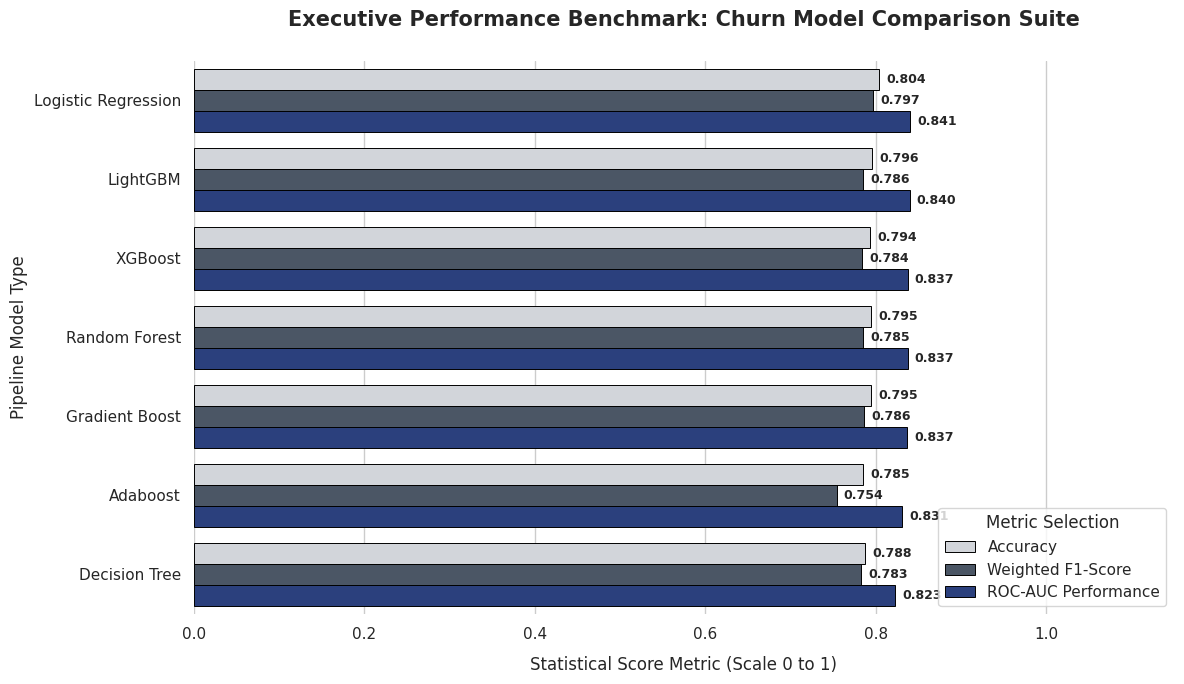

In [43]:
# =====================================================================
# STEP 1: CREATING PERFORMANCE RECORDS 
# =====================================================================
scorecard_records = []

for name, pipeline in models.items():
    y_test_pred = pipeline.predict(X_test_engineered)
    y_test_proba = pipeline.predict_proba(X_test_engineered)[:, 1]

    # Compute metrics cleanly
    accuracy = accuracy_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_test_proba)

    scorecard_records.append({
        "Model Architecture": name,
        "Accuracy": accuracy,
        "Weighted F1-Score": f1,
        "ROC-AUC Performance": roc_auc
    })

# Convert to DataFrame and sort by the leading metric (ROC-AUC)
viz_df = pd.DataFrame(scorecard_records).sort_values(by="ROC-AUC Performance", ascending=False)

# Convert from wide to long format for Seaborn group bars
melted_df = viz_df.melt(
    id_vars="Model Architecture",
    value_vars=["Accuracy", "Weighted F1-Score", "ROC-AUC Performance"],
    var_name="Evaluation Metric",
    value_name="Score"
)

# =====================================================================
# STEP 2: PROFESSIONAL PLOTTING WITH REFINED ACCURACY COLOR
# =====================================================================
sns.set_theme(style="whitegrid", font="sans-serif")
plt.figure(figsize=(12, 7))


professional_palette = ["#d1d5db", "#475569", "#1e3a8a"]

# Generate horizontal grouped layout
ax = sns.barplot(
    data=melted_df,
    y="Model Architecture",
    x="Score",
    hue="Evaluation Metric",
    palette=professional_palette,
    edgecolor="black",
    linewidth=0.7
)

# Title and labeling polishing
plt.title("Executive Performance Benchmark: Churn Model Comparison Suite", fontsize=15, fontweight='bold', pad=25)
plt.xlabel("Statistical Score Metric (Scale 0 to 1)", fontsize=12, labelpad=10)
plt.ylabel("Pipeline Model Type", fontsize=12)
plt.xlim(0, 1.15) # Visual breathing room on right margin for inline metrics

# Clean up axes and place tags
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Metric Selection", loc="lower right", frameon=True)

# Add exact score tags dynamically next to every bar strip
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5, fontsize=9, fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()

# Display the visualization
plt.show()


# <p style="padding:10px; background-color:#1e3a8a; color:white; border-radius:10px; font-size:26px; font-weight:bold; text-align:center;">🏁 Project Conclusion & Final Model Insights</p>

### 🏆 The Winning Architecture: Simplicity Wins
Following a rigorous evaluation across seven distinct machine learning frameworks, **Logistic Regression** emerged as the undisputed optimal model for this project, achieving a leading **ROC-AUC of 0.841**, an **Accuracy of 80.4%**, and a **Weighted F1-Score of 79.7%** on completely unseen testing data. 

While advanced tree-based boosting frameworks like **LightGBM (ROC-AUC: 0.840)** and **XGBoost (ROC-AUC: 0.838)** usually dominate tabular datasets, they failed to outperform our linear baseline. This carries profound business implications:
* 📉 **Robust Generalization:** The gap between Logistic Regression's training set (84.9%) and testing set (84.1%) was almost non-existent. In contrast, complex ensembles like Random Forest exhibited severe overfitting, collapsing from a 95.5% training score down to 83.7% on testing. 
* 🛠️ **The Power of Feature Engineering:** This unusual victory proves that our data preparation phase—specifically the synthesis of the *Financial Burden Ratio*, *Ecosystem Feature Count*, and the *High-Risk Persona Flag*—successfully translated complex, non-linear relationships into clear, linear indicators. Because we solved the complexity in the data step, the algorithm didn't have to guess.

---

### 💼 Executive Business Takeaways & Strategic Recommendations

Based on our final model's mathematical coefficients and the preceding Exploratory Data Analysis, corporate leadership should immediately deploy three targeted retention strategies:

* 🛑 **Dismantle the Month-to-Month "Pricing Wall"**
  * *The Insight:* Month-to-month contracts were flagged by the model as our number-one risk vector, particularly when bills cross the **\$70 to \$100 price bracket**. 
  * *The Action:* The marketing team must design an automated, aggressive incentive campaign to transition short-term users onto 1-year or 2-year contracts, where our data proves churn drops drastically.
* 🛡️ **Deploy Technical Support as a Retention Shield**
  * *The Insight:* Customers lacking active tech support or online security features are nearly three times more likely to leave. However, our multivariate analysis proved that adding tech support to a high-risk month-to-month plan slashes its specific baseline attrition rate from **50.4% down to 30.7%**.
  * *The Action:* Product teams should bundle basic online security or technical assistance directly into initial premium internet onboarding packages to "entangle" users in our ecosystem.
* 💳 **Eliminate Billing Friction on Manual Payments**
  * *The Insight:* Submitting payments via Electronic Checks carries a brutal **45.3% churn rate**, compared to just ~15% for automated options like Credit Cards or automatic bank transfers. 
  * *The Action:* Offer a one-time invoice credit (e.g., \$5 off their next bill) to any customer who switches from a manual electronic check to an automatic billing method, directly removing manual transaction barriers.

---
